# 05 Evaluation And Diagnostics

In [ ]:
# Notebook 05: Evaluation and diagnostics

# Reloading utility functions
import importlib
import utils.model_utils
importlib.reload(utils.model_utils)

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.data_utils import project_root
from utils.model_utils import correlation_metrics, regression_metrics

ROOT = project_root()
IN_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIG_DIR = ROOT / "reports" / "figures"
TAB_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Loading the held-out test set that was not used during training or tuning

X_test = pd.read_parquet(IN_DIR / "X_test_pca.parquet")
y_test = pd.read_parquet(IN_DIR / "y_test.parquet")["log_ic50"]

# Collecting saved models from previous notebooks
model_files = {
     "dummy_mean": MODELS_DIR / "dummy_mean.joblib",
    "ridge": MODELS_DIR / "ridge_best.joblib",
    "lasso": MODELS_DIR / "lasso_best.joblib",
    "elasticnet": MODELS_DIR / "elasticnet_best.joblib",
    "svr": MODELS_DIR / "svr_best.joblib",
    "random_forest": MODELS_DIR / "rf_best.joblib",
    "xgboost": MODELS_DIR / "xgb_best.joblib",
}

# Evaluating on the held-out test set

rows = []
predictions = {}
for name, path in model_files.items():
    if not path.exists():
        continue
    model = joblib.load(path)
    pred = model.predict(X_test)
    predictions[name] = pred
    row = {"model": name}
    row.update(regression_metrics(y_test, pred))
    row.update(correlation_metrics(y_test, pred))
    rows.append(row)


In [2]:
# Save the final test set comparison table
results = pd.DataFrame(rows).sort_values("r2", ascending=False).reset_index(drop=True)
results.to_csv(TAB_DIR / "test_set_model_comparison.csv", index=False)
results



,model,rmse,mae,r2,pearson_r,spearman_r
0,ridge,1.167934,0.950006,0.211302,0.464418,0.440692
1,svr,1.204006,0.936554,0.161831,0.404423,0.408529
2,elasticnet,1.204545,0.931133,0.161081,0.417117,0.406181
3,xgboost,1.217572,0.936126,0.142838,0.378598,0.362102
4,random_forest,1.219783,0.956233,0.139721,0.397827,0.387644
5,lasso,1.220517,0.938991,0.138686,0.389420,0.378430
6,dummy_mean,1.315181,1.049111,-0.000103,NaN,NaN


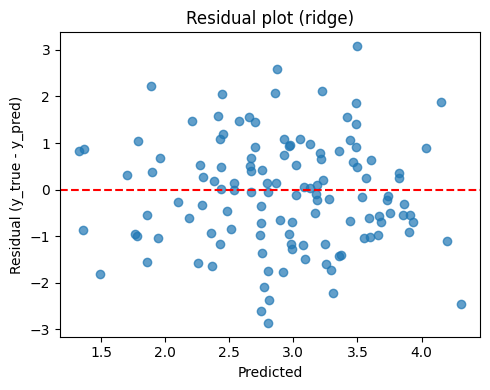

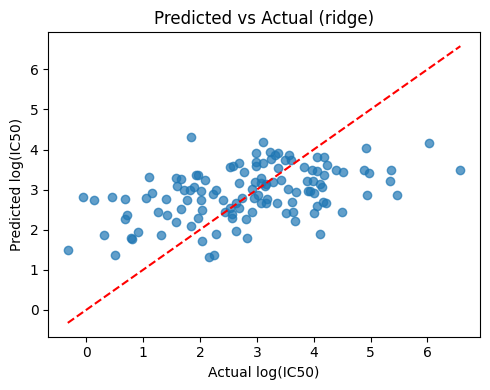

In [3]:
# Select the best model based on test R² for diagnostic plots
best_model = results.loc[0, "model"]
best_pred = predictions[best_model]
residuals = y_test.values - best_pred

# Residual plot
plt.figure(figsize=(5, 4))
plt.scatter(best_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual (y_true - y_pred)")
plt.title(f"Residual plot ({best_model})")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_plot_best_model.png", dpi=150)
plt.show()

# Predicted vs actual plot
plt.figure(figsize=(5, 4))
plt.scatter(y_test, best_pred, alpha=0.7)
mn = min(y_test.min(), np.min(best_pred))
mx = max(y_test.max(), np.max(best_pred))
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Actual log(IC50)")
plt.ylabel("Predicted log(IC50)")
plt.title(f"Predicted vs Actual ({best_model})")
plt.tight_layout()
plt.savefig(FIG_DIR / "pred_vs_actual_best_model.png", dpi=150)
plt.show()


## Final Evaluation on Held-Out Test Set — Results

### Design Choices for Evaluation
The test set (20% of the full dataset, ~124 samples) was held out from the very 
beginning in Notebook 02 and never used during training or hyperparameter tuning. 
This ensures the final evaluation reflects true generalization performance on 
completely unseen data.

Five metrics are reported:
- **RMSE and MAE**: Error in log IC50 units — lower is better. MAE is the primary 
  error metric as it is more robust to outliers in drug sensitivity data 
  (Tang & Gottlieb, 2021).
- **R²**: Proportion of IC50 variance explained — higher is better. 
- **Pearson r**: Measures linear correlation between predicted and actual IC50. 
  Directly comparable to published benchmarks which commonly report this metric.
- **Spearman r**: Measures rank correlation — whether the model correctly orders 
  cell lines by sensitivity even if the absolute values are off. Useful for 
  precision oncology applications where ranking matters more than exact values.

### Test Set Model Comparison
| Model | RMSE | MAE | R² | Pearson r | Spearman r |
|---|---|---|---|---|---|
| **Ridge** | **1.168** | **0.950** | **0.211** | **0.464** | **0.441** |
| SVR | 1.204 | 0.937 | 0.162 | 0.404 | 0.409 |
| ElasticNet | 1.205 | 0.931 | 0.161 | 0.417 | 0.406 |
| XGBoost | 1.218 | 0.936 | 0.143 | 0.379 | 0.362 |
| Random Forest | 1.220 | 0.956 | 0.140 | 0.398 | 0.388 |
| Lasso | 1.221 | 0.939 | 0.139 | 0.389 | 0.378 |
| Dummy baseline | 1.315 | 1.049 | ~0 | — | — |

Ridge performed best overall across RMSE, R², and Pearson r. All six trained 
models outperformed the dummy baseline, suggesting that gene expression carries 
meaningful predictive signal for Erlotinib sensitivity.

### Best Model: Ridge (alpha=1000)
Ridge regression achieved the best test set performance with R² = 0.211 and 
Pearson r = 0.464. This is notably better than its validation set ranking, where 
SVR ranked first. This swap is a known consequence of model selection on a 
finite validation set — the validation set is only ~123 samples, which can introduce some variability in model rankings.
The test set result is the more reliable estimate of 
true generalization performance.

Ridge's strong generalization makes intuitive sense here. With 100 PCA components 
and only ~370 training samples, simpler models with strong regularization tend to 
generalize better than more flexible ones. Ridge shrinks all coefficients uniformly, 
effectively averaging signal across all components rather than overfitting to any 
particular one.

### Interpreting the Correlation Results
Pearson r = 0.464 shows a moderate positive relationship between predicted and actual log IC50 values, meaning the model captures the overall trend in drug sensitivity. Cell lines that are more sensitive generally get lower predicted IC50 values. Spearman r = 0.441 is close to Pearson r, which suggests the ranking is also fairly consistent, with no major reversals.

These values are directly comparable to published benchmarks. The DREAM Drug 
Sensitivity Prediction Challenge (Costello et al., 2014, *Nature Biotechnology*) 
reported Pearson correlations of 0.3–0.5 for top-performing teams predicting 
Erlotinib sensitivity from expression features, suggesting that the Ridge result 
is within the typical range reported for expression-only models.

### Comparison to Recent Published Benchmarks
Our results are consistent with the expression-only prediction literature. PathDSP (Tang & Gottlieb, 2021) showed that classical ML models such as ElasticNet and SVM remain competitive with deep learning when using gene expression features alone.

Methods reporting higher performance (R² > 0.7), such as Precily (Sharifi-Noghabi et al., 2022, Nature Communications) and XGraphCDS (2023), incorporate additional data types such as drug chemical structure alongside gene expression, resulting in a richer feature representation. The gap between our results and these methods is therefore expected and not necessarily a limitation of the modeling approach itself.

### Reading the Plots

**Residual plot**: Residuals are roughly centered around zero across the prediction range, indicating no strong systematic bias. The spread is fairly uniform, which suggests that the errors are mostly random rather than following a clear pattern (for example, consistently underpredicting high IC50 values). A few larger residuals at the extremes reflect the difficulty of predicting outlier cell lines using expression data alone.

**Predicted vs Actual**: The points follow a general diagonal trend with some scatter, consistent with R² = 0.211. This indicates that the model captures the overall direction of drug sensitivity across cell lines, but not all values are predicted accurately. The tendency of predictions to cluster toward the center (regression toward the mean) is expected for regularized linear models when performance is moderate.

### Saved Artifacts
- `residual_plot_best_model.png`
- `pred_vs_actual_best_model.png`
- `test_set_model_comparison.csv`

## References

- Tang, Y.-C., & Gottlieb, A. (2021). Explainable drug sensitivity prediction 
through cancer pathway enrichment. Scientific Reports, 11, 3128. 
https://doi.org/10.1038/s41598-021-82612-7

- Costello, J.C., et al. (2014). A community effort to assess and improve drug 
  sensitivity prediction algorithms. *Nature Biotechnology*, 32, 1202–1212.
  https://www.nature.com/articles/nbt.2877

- Sharifi-Noghabi, H., et al. (2022). Gene expression based inference of cancer 
  drug sensitivity. *Nature Communications*, 13, 5680.
  https://www.nature.com/articles/s41467-022-33291-z